# Experiment C - Reconstruction-Trained Acceleration CNN

**Question:** how much character-discriminative information is recoverable when the classifier is trained directly on reconstructed acceleration?

Strict protocol:

1. Reuse Experiment A's **train / validation / test users** and `class_to_idx` from the A checkpoint.
2. Use the A checkpoint **only for split/class metadata**. Do **not** load A model weights.
3. Fit acceleration normalization using **reconstruction train valid samples only**.
4. Train a new `MaskAwareAccelerationCNN` from scratch on reconstruction train.
5. Select the best epoch using reconstruction validation balanced accuracy.
6. Evaluate on reconstruction test with the shared representation protocol.
7. Use the same selected dataset roots as the A checkpoint; changing the action/sample cohort requires regenerating A.

This notebook is intentionally thin. The executable experiment lives in `scripts/run_experiment_c.py`; the reusable implementation lives in `snn/accel_reconstruction_eval/`.


In [1]:
from __future__ import annotations

from dataclasses import replace
import json
from pathlib import Path
import sys

import pandas as pd
import torch


def find_repository_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate repository root containing the 'snn' directory."
    )


REPOSITORY_ROOT = find_repository_root(Path.cwd())
SCRIPTS_DIR = REPOSITORY_ROOT / "scripts"

if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from snn.accel_reconstruction_eval import experiment_c_config
from run_experiment_c import run_experiment_c

print("Repository root:", REPOSITORY_ROOT)
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/ted/project/writingring-viz
CUDA available: True


## Paths and experiment controls

The reference checkpoint is the Experiment A checkpoint. It is used only to recover the exact user split and class mapping. Experiment C does not reuse its weights or normalization statistics.

Regenerate Experiment A before running B/C/D whenever A's exclusions change. C keeps strict reference mode and has no local cohort or explicit-split override.


In [2]:
# Select the same one or two roots used to produce REFERENCE_A_CHECKPOINT.
# Roots remain separate on disk and are combined only in the shared loader.
DATASET_ROOTS = [
    Path("outputs/action0_rectified/low-pass/aligned-board-events"),
    Path("outputs/action1_rectified/low-pass/aligned-board-events"),
]
REFERENCE_A_CHECKPOINT = Path(
    "notebooks/artifacts/acceleration_cnn_representation/"
    "best_acceleration_cnn.pt"
)
OUTPUT_DIR = Path(
    "notebooks/artifacts/experiment_C_reconstruction_trained"
)

# Keep this False for strict A/B/C comparability.
ALLOW_NEW_SPLIT = False

# Optional training overrides. These defaults match the current CNN baseline.
NUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 10
BATCH_SIZE = 128
NUM_WORKERS = 0
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
USE_CLASS_WEIGHTS = False
GRAD_CLIP_NORM = None
MAX_TRAIN_BATCHES = None
USE_GPU = True


## Build the Experiment C configuration

Only the training/runtime settings below are modified. The Experiment C domain contract remains fixed as:

- train source = reconstruction
- validation source = reconstruction
- test source = reconstruction
- normalization source = reconstruction train


In [3]:
config = experiment_c_config(
    output_dir=OUTPUT_DIR,
    random_seed=12345,
)

config = replace(
    config,
    use_gpu=USE_GPU,
    loader=replace(
        config.loader,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
    ),
    training=replace(
        config.training,
        num_epochs=NUM_EPOCHS,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        use_class_weights=USE_CLASS_WEIGHTS,
        grad_clip_norm=GRAD_CLIP_NORM,
        max_train_batches=MAX_TRAIN_BATCHES,
    ),
)
config.validate()
config.to_dict()


{'name': 'C_reconstruction',
 'train_source': 'reconstruction',
 'val_source': 'reconstruction',
 'test_source': 'reconstruction',
 'normalization_source': 'reconstruction',
 'training_enabled': True,
 'random_seed': 12345,
 'use_gpu': True,
 'normalization_chunk_segments': 256,
 'split': {'train_fraction': 0.7,
  'val_fraction': 0.15,
  'explicit_train_users': None,
  'explicit_val_users': None,
  'explicit_test_users': None,
  'require_all_users_assigned': True,
  'require_all_labels_in_all_splits': True,
  'excluded_users': (),
  'included_labels': None},
 'loader': {'batch_size': 128,
  'num_workers': 0,
  'pin_memory': None,
  'persistent_workers': None},
 'training': {'num_epochs': 30,
  'learning_rate': 0.0005,
  'weight_decay': 0.0,
  'use_class_weights': False,
  'early_stopping_patience': 10,
  'max_train_batches': None,
  'grad_clip_norm': None},
 'evaluation': {'k_values': (1, 3, 5, 10, 20, 50),
  'knn_k_candidates': (1, 3, 5, 7, 10, 15, 20),
  'similarity_query_batch_size'

## Run Experiment C

This call performs the complete pipeline:

`load -> recover A split -> fit recon normalization -> train from scratch -> select best epoch -> extract embeddings -> evaluate -> save artifacts`


In [4]:
run = run_experiment_c(
    root=DATASET_ROOTS,
    repository_root=REPOSITORY_ROOT,
    output_dir=OUTPUT_DIR,
    reference_checkpoint=REFERENCE_A_CHECKPOINT,
    config=config,
    allow_new_split=ALLOW_NEW_SPLIT,
)


Epoch 001 | train loss=2.38803, BA=0.14826 | val loss=2.45534, BA=0.08333
Epoch 002 | train loss=2.18319, BA=0.24908 | val loss=2.39052, BA=0.11944
Epoch 003 | train loss=2.06764, BA=0.31387 | val loss=2.28710, BA=0.19861
Epoch 004 | train loss=1.98016, BA=0.36205 | val loss=2.16201, BA=0.30088
Epoch 005 | train loss=1.88815, BA=0.40968 | val loss=2.10124, BA=0.29621
Epoch 006 | train loss=1.81949, BA=0.44046 | val loss=1.98427, BA=0.29940
Epoch 007 | train loss=1.75450, BA=0.44300 | val loss=1.82244, BA=0.47150
Epoch 008 | train loss=1.69364, BA=0.47196 | val loss=1.73435, BA=0.49565
Epoch 009 | train loss=1.61041, BA=0.54266 | val loss=1.79746, BA=0.44212
Epoch 010 | train loss=1.56080, BA=0.58149 | val loss=1.60858, BA=0.54410
Epoch 011 | train loss=1.48946, BA=0.60722 | val loss=1.60208, BA=0.56462
Epoch 012 | train loss=1.44384, BA=0.63730 | val loss=1.58606, BA=0.50698
Epoch 013 | train loss=1.37731, BA=0.65023 | val loss=1.62017, BA=0.43166
Epoch 014 | train loss=1.34785, BA=0.6

## Inherited cohort provenance

Experiment C inherits the cohort from the authoritative A checkpoint.


In [5]:
provenance = json.loads(
    (run.output_dir / "provenance.json").read_text(encoding="utf-8")
)
display(
    pd.Series(
        {
            "cohort_source": provenance["cohort_source"],
            "excluded_users": provenance["excluded_users"],
            "eligible_users": provenance["eligible_users"],
            "train_users": provenance["train_users"],
            "val_users": provenance["val_users"],
            "test_users": provenance["test_users"],
            "class_to_idx": provenance["class_to_idx"],
        },
        name="Inherited cohort",
    )
)


cohort_source                                            checkpoint
excluded_users                                                   []
eligible_users    [user_0, user_1, user_2, user_3, user_4, user_...
train_users       [user_0, user_1, user_3, user_4, user_5, user_...
val_users                                [user_8, user_14, user_20]
test_users                               [user_2, user_13, user_16]
class_to_idx      {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'G': ...
Name: Inherited cohort, dtype: object

## Primary results

In [6]:
display(run.summary.T.rename(columns={0: "Experiment C"}))


,Experiment C
CNN_test_balanced_accuracy,0.527086
CNN_test_accuracy,0.535433
CNN_test_macro_f1,0.511598
kNN_selected_k,15.000000
kNN_test_balanced_accuracy,0.583484
kNN_test_accuracy,0.590551
kNN_test_macro_f1,0.550556
prototype_test_balanced_accuracy,0.565085
prototype_test_accuracy,0.559055
prototype_test_macro_f1,0.534795


## CNN classification across splits

In [7]:
display(run.classification_splits)


,accuracy,balanced_accuracy,macro_f1,weighted_f1,loss
split,,,,,
train,0.631659,0.625097,0.617356,0.617084,1.520246
val,0.566929,0.564619,0.523164,0.528584,1.602084
test,0.535433,0.527086,0.511598,0.507544,1.749211


## Split contract

In [8]:
display(run.split_summary)
display(run.label_split_counts)


,users,samples,labels
split,,,
train,14,657,12
val,3,127,12
test,3,127,12


split,train,val,test
label,,,
A,51,10,11
B,56,10,9
C,60,12,12
D,58,11,11
E,58,10,12
G,52,12,12
H,61,12,12
I,57,12,11
J,58,11,12


## Reconstruction-train normalization

In [9]:
pd.DataFrame(
    {
        "channel": ["x", "y", "z"],
        "mean": run.normalization.mean,
        "std": run.normalization.std,
    }
).assign(
    fitted_on=run.normalization.fitted_on,
    valid_time_points=run.normalization.valid_time_points,
)


,channel,mean,std,fitted_on,valid_time_points
0,x,-0.258029,1.211700,reconstruction:train,202358
1,y,0.094274,1.253918,reconstruction:train,202358
2,z,0.042538,0.829966,reconstruction:train,202358


## Training history

In [10]:
display(run.training_history.tail(20))


,epoch,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,loss
22,12,train,0.643836,0.637301,0.638358,0.638731,1.443843
23,12,val,0.519685,0.506981,0.464712,0.467107,1.586060
24,13,train,0.665145,0.650225,0.655101,0.660865,1.377314
25,13,val,0.440945,0.431665,0.446077,0.445008,1.620169
26,14,train,0.660578,0.642638,0.643114,0.651872,1.347849
27,14,val,0.519685,0.501308,0.486443,0.494069,1.565112
28,15,train,0.703196,0.691718,0.698769,0.703084,1.303135
29,15,val,0.456693,0.454897,0.393658,0.388349,1.680707
30,16,train,0.694064,0.686659,0.691422,0.693289,1.263654
31,16,val,0.519685,0.515981,0.471264,0.471261,1.537012


## Saved artifacts

In [11]:
artifact_table = pd.DataFrame(
    [
        {"artifact": name, "path": str(path)}
        for name, path in sorted(run.artifact_paths.items())
    ]
)
display(artifact_table)


,artifact,path
0,checkpoint,/home/ted/project/writingring-viz/notebooks/ar...
1,classification_splits,/home/ted/project/writingring-viz/notebooks/ar...
2,embeddings_test,/home/ted/project/writingring-viz/notebooks/ar...
3,embeddings_train,/home/ted/project/writingring-viz/notebooks/ar...
4,embeddings_val,/home/ted/project/writingring-viz/notebooks/ar...
5,evaluation_arrays,/home/ted/project/writingring-viz/notebooks/ar...
6,evaluation_geometry,/home/ted/project/writingring-viz/notebooks/ar...
7,evaluation_intra_by_class,/home/ted/project/writingring-viz/notebooks/ar...
8,evaluation_knn_validation,/home/ted/project/writingring-viz/notebooks/ar...
9,evaluation_linear_probe,/home/ted/project/writingring-viz/notebooks/ar...


# Visualization

The cells below are presentation-only. They consume the metrics and embeddings already generated by `run_experiment_c()`.

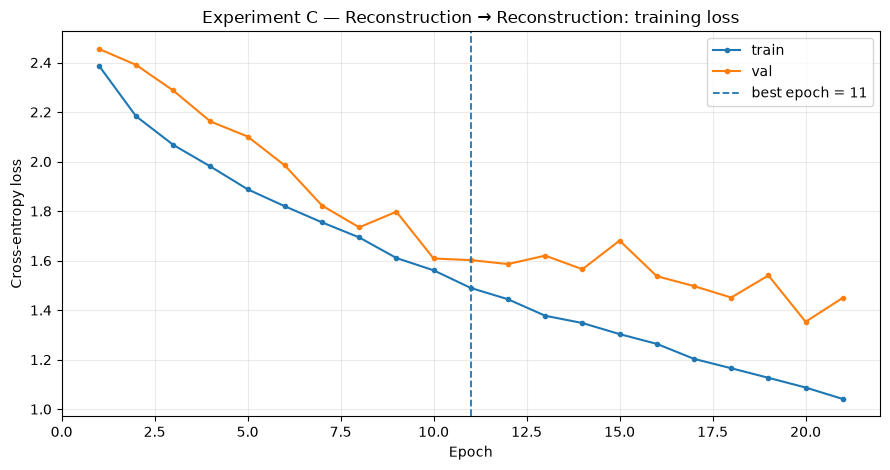

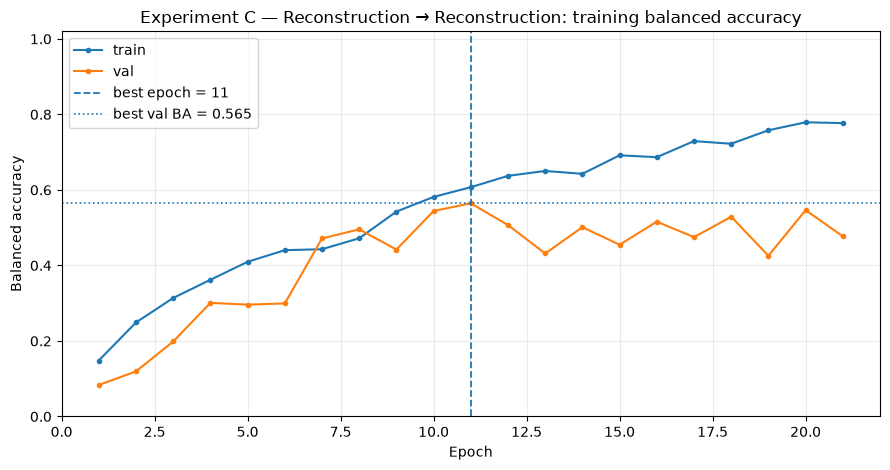

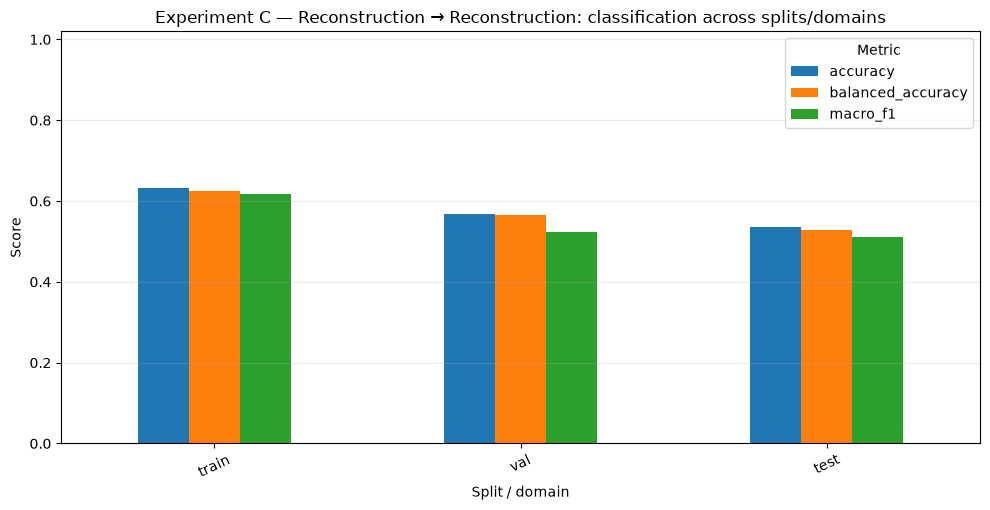

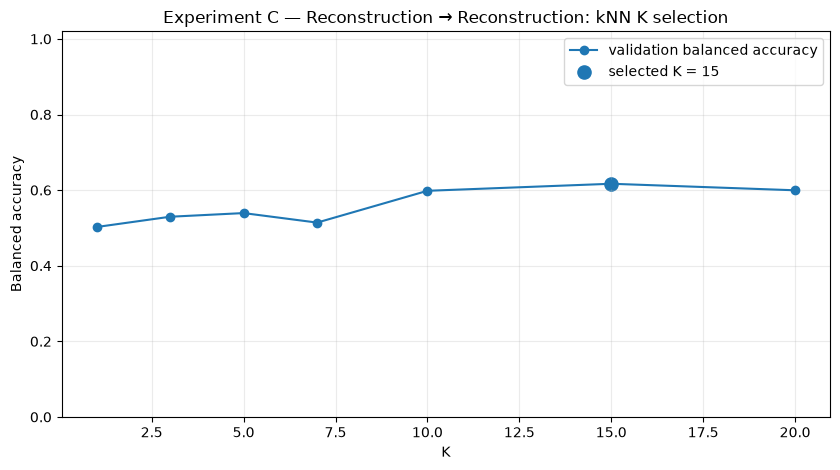

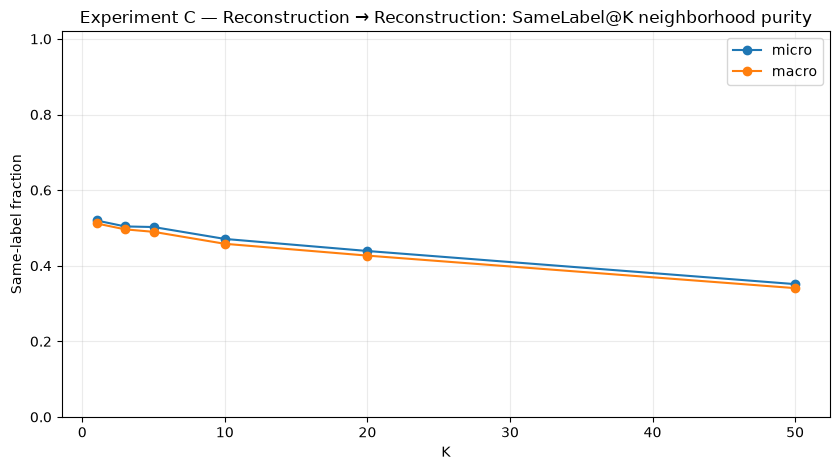

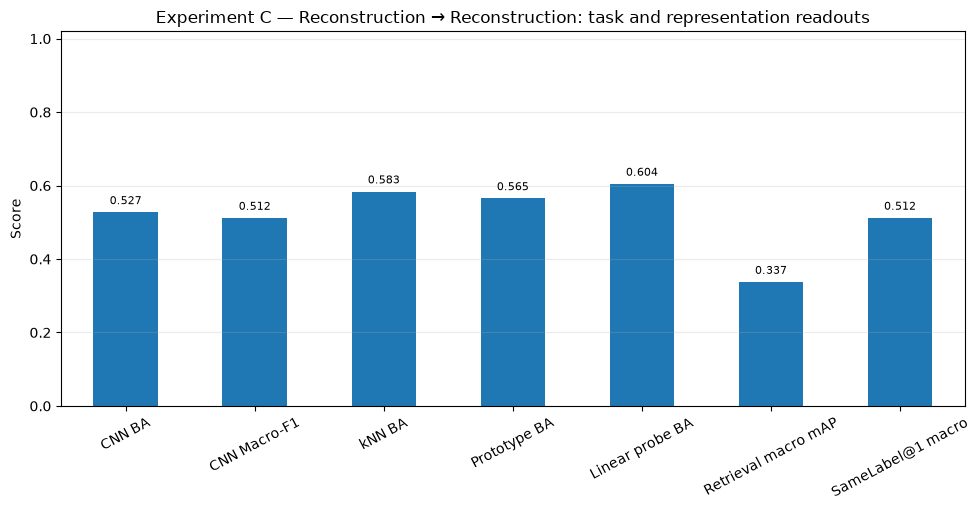

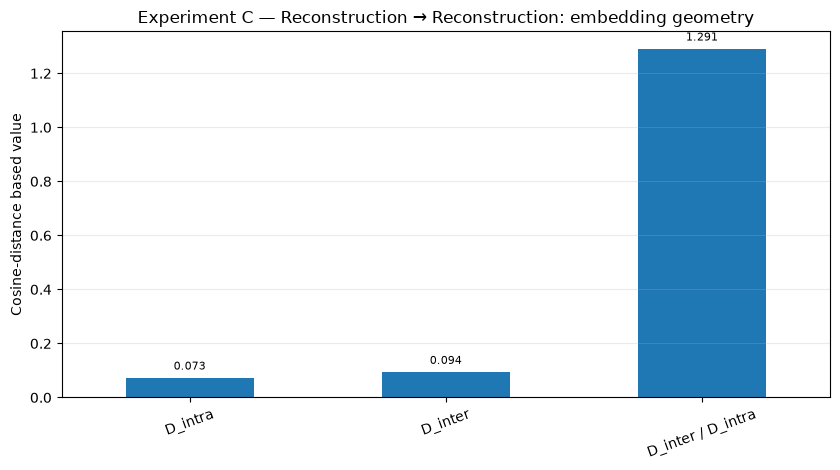

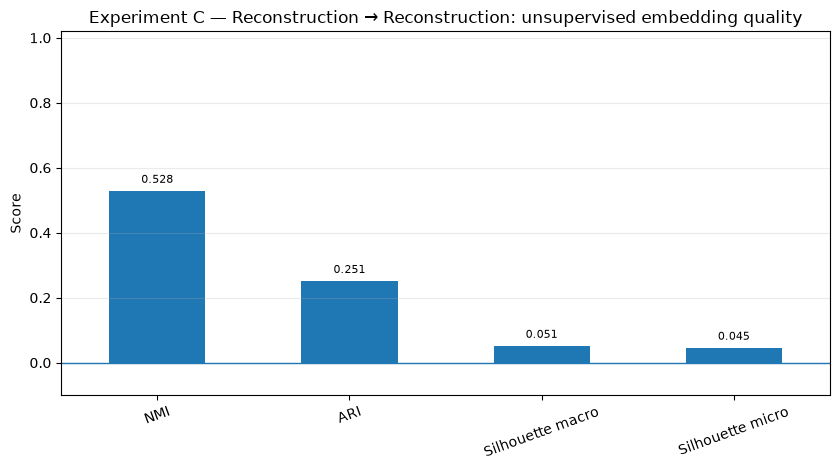

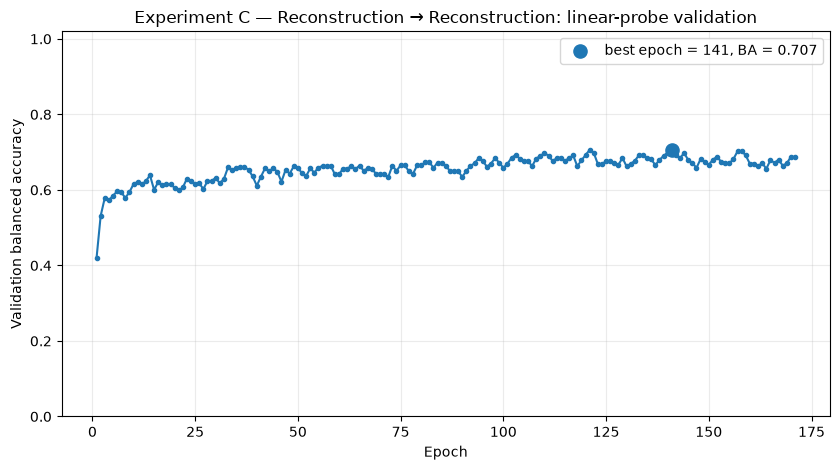

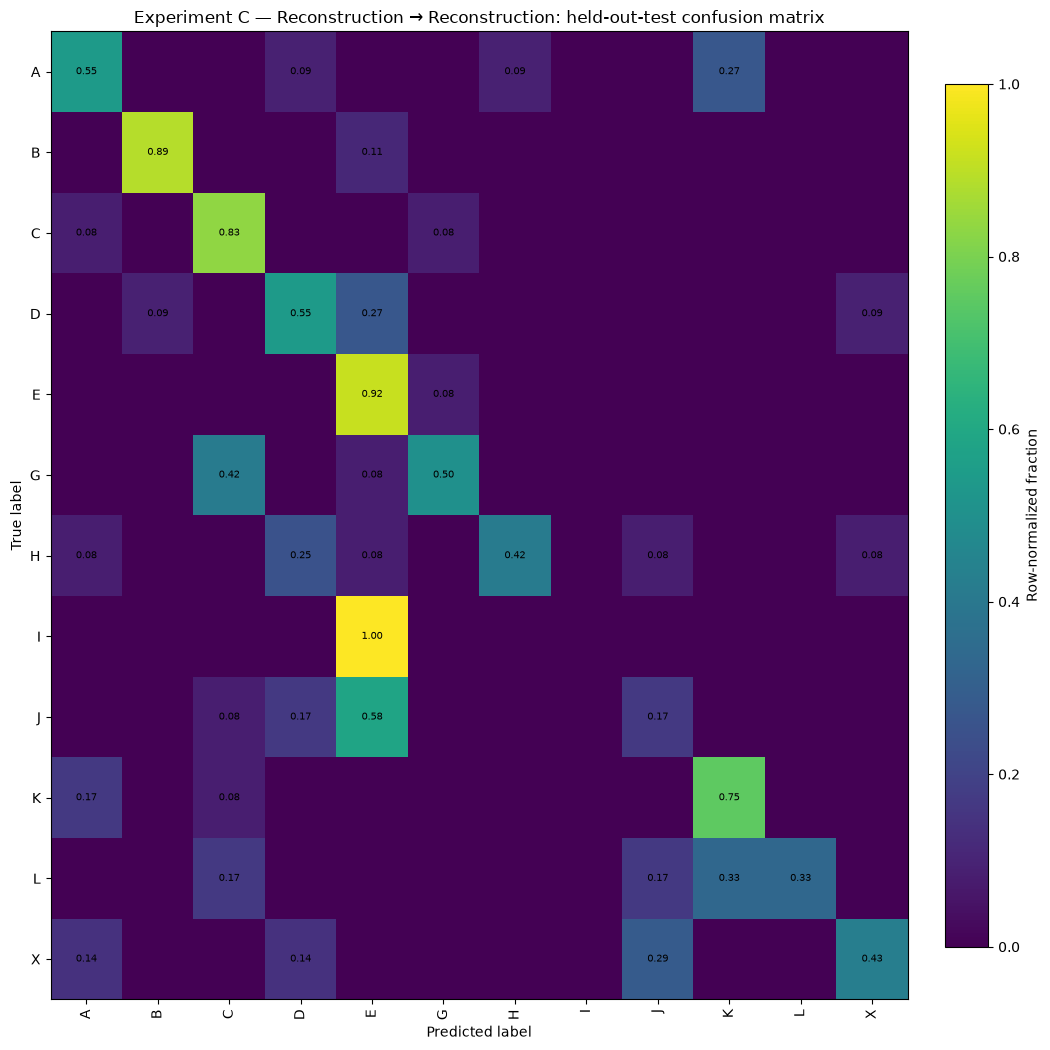

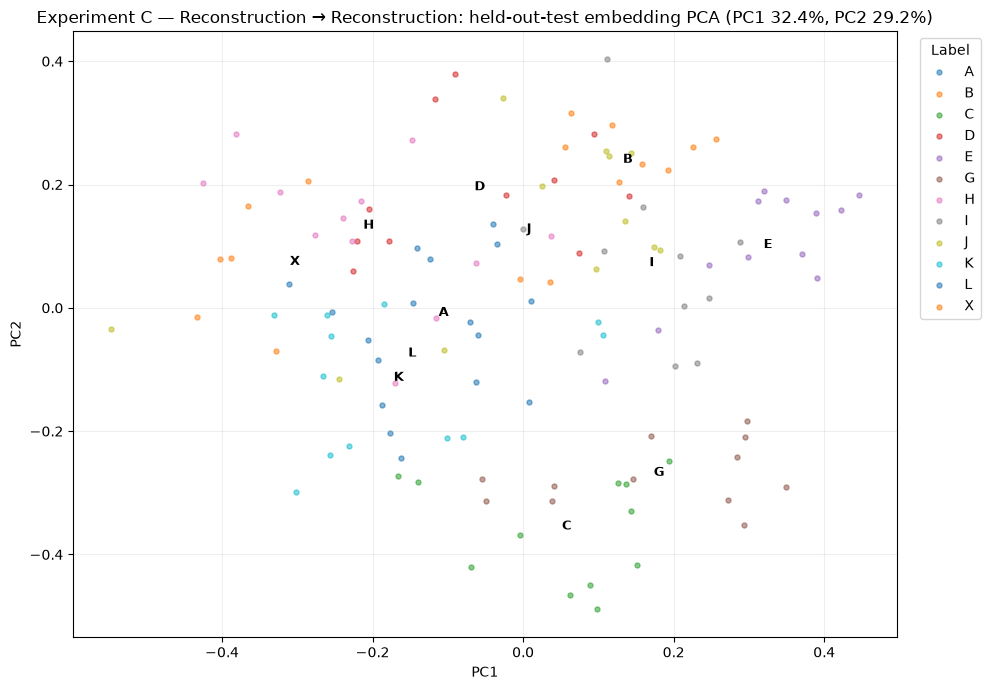

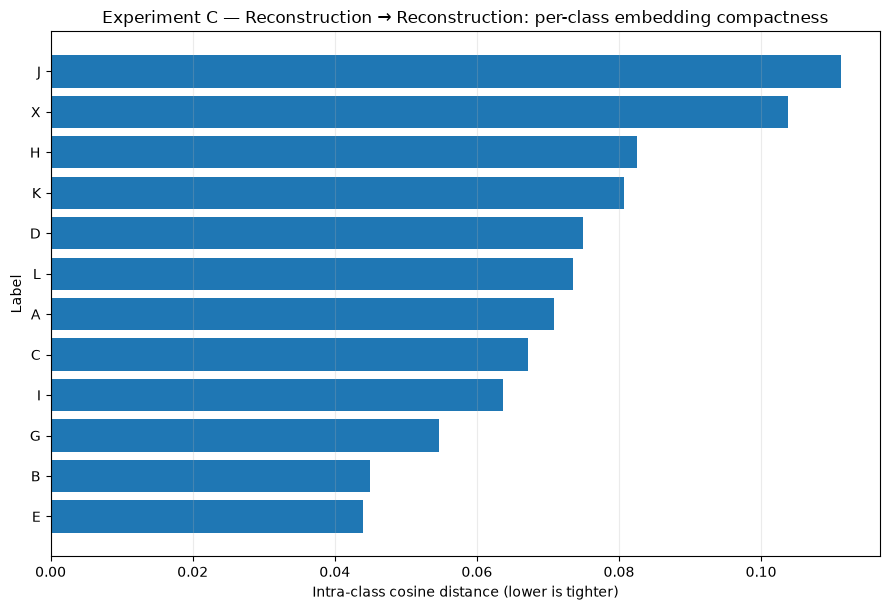

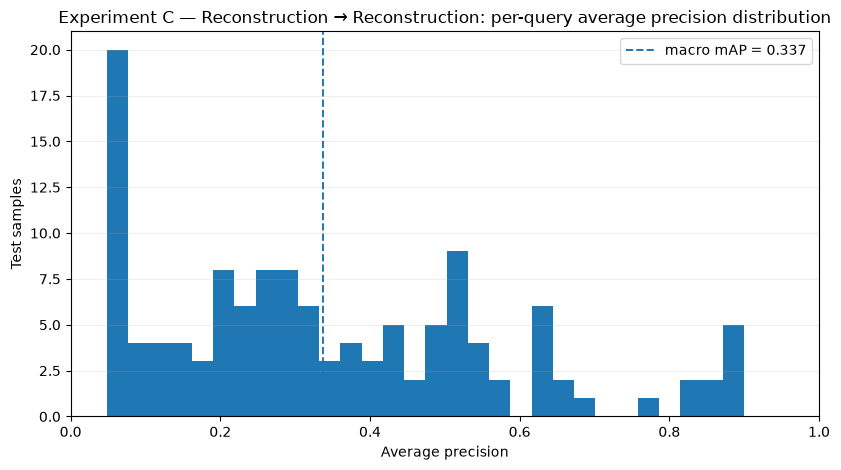

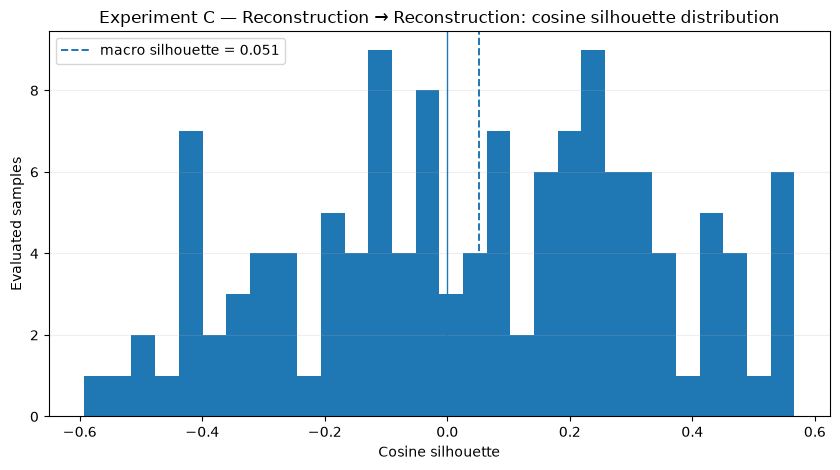

In [12]:
from snn.accel_reconstruction_eval.visualization import visualize_experiment_c

figures = visualize_experiment_c(run.output_dir)

## How to interpret C together with A and B

The key comparison is not B alone:

- **A high, B low, C approximately A:** reconstruction still contains task information; the main problem is raw-to-reconstruction domain shift.
- **A high, B low, C also low:** reconstruction has likely removed task-relevant information.
- **C > A:** reconstruction may provide a useful denoising or bottleneck effect; confirm this with geometry/retrieval metrics and repeated seeds before making a strong claim.

The final A/B/C comparison should use the same user split, class mapping, CNN architecture, and metric implementation.
